# CustomerLens — RFM Analysis & Customer Behavioral Profiling

## Transforming Transaction Logs into Quantifiable Behavioral Features

---

### Executive Objectives & Analytical Scope

In **CustomerLens**, Phases 4 through 7 established an enterprise-grade transactional foundation: ingesting, cleaning, exploring, and modeling 392,692 validated customer transactions across PostgreSQL and Python.

The objective of **Phase 8** is to engineer customer-level behavioral representations using the classical **RFM (Recency, Frequency, Monetary)** framework:
1. **Recency ($R$):** Days elapsed since the customer's most recent completed order relative to the dataset snapshot anchor (`2011-12-10 12:50:00`).
2. **Frequency ($F$):** Number of distinct completed checkout orders (`nunique InvoiceNo`).
3. **Monetary ($M$):** Total gross financial spend across all completed sales (`sum Revenue`).

---

### Methodological Principles & Guardrails
- **Deterministic & Reproducible:** Computations are vectorized and verified against known empirical baselines.
- **Outlier Preservation:** Statistically extreme customers (e.g. large wholesale accounts) represent genuine commercial behavior and are retained, not discarded.
- **Safe Tied-Boundary Scoring:** Quantile scoring gracefully resolves tied values (such as order frequencies with discrete masses at 1 and 2).
- **Hypothesis-Driven Interpretation:** Segment labels (*Champions*, *Loyal Customers*, *At Risk*, etc.) represent descriptive behavioral groupings rather than psychological certainty or guaranteed campaign ROI.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is on sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.rfm import (
    load_customer_transactions,
    calculate_rfm,
    validate_rfm,
    calculate_rfm_scores,
    assign_rfm_segments,
    summarize_rfm,
    save_rfm_dataset,
)

# Plotting styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "figure.dpi": 150,
})

print("Environment configured successfully. Ready for RFM analysis.")


Environment configured successfully. Ready for RFM analysis.


---

## 1. Data Ingestion & Transaction Baseline Verification

We load the primary customer transactions dataset (`data/processed/customer_transactions.csv`) and verify the known empirical baselines:
- **Total Records:** 392,692 rows
- **Unique Customers:** 4,338
- **Completed Orders:** 18,532
- **Gross Revenue:** £8,887,208.89
- **Date Range:** 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [2]:
tx_df = load_customer_transactions()

total_rows = len(tx_df)
unique_custs = tx_df["CustomerID"].nunique()
unique_orders = tx_df["InvoiceNo"].nunique()
total_rev = tx_df["Revenue"].sum()
min_date = tx_df["InvoiceDate"].min()
max_date = tx_df["InvoiceDate"].max()
ref_date = max_date + pd.Timedelta(days=1)

print("=" * 60)
print("CUSTOMER TRANSACTIONS BASELINE VERIFICATION")
print("=" * 60)
print(f"Total Rows           : {total_rows:,}")
print(f"Active Customers     : {unique_custs:,}")
print(f"Completed Orders     : {unique_orders:,}")
print(f"Total Gross Revenue  : £{total_rev:,.2f}")
print(f"Earliest InvoiceDate : {min_date}")
print(f"Latest InvoiceDate   : {max_date}")
print(f"Dynamic Ref Date     : {ref_date}")
print("=" * 60)

assert total_rows == 392692, "Row count mismatch"
assert unique_custs == 4338, "Customer count mismatch"
assert unique_orders == 18532, "Order count mismatch"
assert round(total_rev, 2) == 8887208.89, "Revenue mismatch"
print("All source transaction invariants successfully verified!")


CUSTOMER TRANSACTIONS BASELINE VERIFICATION
Total Rows           : 392,692
Active Customers     : 4,338
Completed Orders     : 18,532
Total Gross Revenue  : £8,887,208.89
Earliest InvoiceDate : 2010-12-01 08:26:00
Latest InvoiceDate   : 2011-12-09 12:50:00
Dynamic Ref Date     : 2011-12-10 12:50:00
All source transaction invariants successfully verified!


---

## 2. Raw RFM Metric Computation & Invariant Validation

We aggregate the transaction records into customer-level RFM features using `src.rfm.calculate_rfm()` and run `validate_rfm()` to guarantee:
1. Exactly one row per customer (`4,338` rows).
2. Zero duplicate or null customer IDs.
3. Non-negative Recency, Frequency $\ge 1$, Monetary $> 0$.
4. Strict conservation of total orders (`18,532`) and total revenue (`£8,887,208.89`).


In [3]:
rfm = calculate_rfm(tx_df, reference_date=ref_date)
validation = validate_rfm(rfm, source_df=tx_df)

print("=" * 60)
print("RFM DATASET VALIDATION SCORECARD")
print("=" * 60)
for k, v in validation.items():
    print(f"{k:20}: {v}")
print("=" * 60)

display(rfm.head(10))


RFM DATASET VALIDATION SCORECARD
status              : PASSED
total_customers     : 4338
unique_customers    : 4338
total_frequency     : 18532
total_monetary      : 8887208.89
min_recency         : 1
max_recency         : 374
min_frequency       : 1
max_frequency       : 209
min_monetary        : 3.75
max_monetary        : 280206.02


,customerid,recency,frequency,monetary,first_purchase_date,last_purchase_date,country
0,14646,2,73,280206.02,2010-12-20 10:09:00,2011-12-08 12:12:00,Netherlands
1,18102,1,60,259657.30,2010-12-07 16:42:00,2011-12-09 11:50:00,United Kingdom
2,17450,8,46,194390.79,2010-12-07 09:23:00,2011-12-01 13:29:00,United Kingdom
3,16446,1,2,168472.50,2011-05-18 09:52:00,2011-12-09 09:15:00,United Kingdom
4,14911,1,201,143711.17,2010-12-01 14:05:00,2011-12-08 15:54:00,EIRE
5,12415,24,21,124914.53,2011-01-06 11:12:00,2011-11-15 14:22:00,Australia
6,14156,10,55,117210.08,2010-12-03 11:48:00,2011-11-30 10:54:00,EIRE
7,17511,3,31,91062.38,2010-12-01 10:19:00,2011-12-07 10:12:00,United Kingdom
8,16029,39,63,80850.84,2010-12-01 09:57:00,2011-11-01 10:27:00,United Kingdom
9,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom


---

## 3. Parametric & Non-Parametric Summary Statistics

E-commerce customer spend and purchase frequencies routinely exhibit heavy right-skewness (Pareto distributions). We report both parametric metrics (mean, standard deviation) and non-parametric metrics (median, IQR, percentiles) to accurately capture the central tendency and dispersion.


In [4]:
def get_extended_stats(df, cols):
    stats = []
    for col in cols:
        s = df[col]
        q25, q50, q75 = s.quantile([0.25, 0.50, 0.75])
        iqr = q75 - q25
        stats.append({
            "Feature": col,
            "Count": len(s),
            "Mean": round(s.mean(), 2),
            "Std": round(s.std(), 2),
            "Min": round(s.min(), 2),
            "P25 (Q1)": round(q25, 2),
            "Median (P50)": round(q50, 2),
            "P75 (Q3)": round(q75, 2),
            "P90": round(s.quantile(0.90), 2),
            "P95": round(s.quantile(0.95), 2),
            "P99": round(s.quantile(0.99), 2),
            "Max": round(s.max(), 2),
            "IQR": round(iqr, 2),
            "Skewness": round(s.skew(), 2),
        })
    return pd.DataFrame(stats)

stats_df = get_extended_stats(rfm, ["recency", "frequency", "monetary"])
display(stats_df)


,Feature,Count,Mean,Std,Min,P25 (Q1),Median (P50),P75 (Q3),P90,P95,P99,Max,IQR,Skewness
0,recency,4338,92.54,100.01,1.00,18.00,51.00,142.0,263.00,312.0,369.00,374.00,124.00,1.25
1,frequency,4338,4.27,7.70,1.00,1.00,2.00,5.0,9.00,13.0,30.00,209.00,4.00,12.07
2,monetary,4338,2048.69,8985.23,3.75,306.48,668.57,1660.6,3640.84,5790.0,19780.49,280206.02,1354.12,19.34


---

## 4. Distribution Visualizations: Raw vs. Log-Transformed Perspectives

We visualize the distributions of Recency, Frequency, and Monetary using kernel density estimates (KDE) and histograms.
- **Raw Distributions:** Highlight positive skewness and long right tails in Frequency and Monetary spend.
- **Log-Transformed Visualizations:** Using $\log(x + 1)$ stabilizes variance to reveal underlying multimodal structures without altering raw customer values.


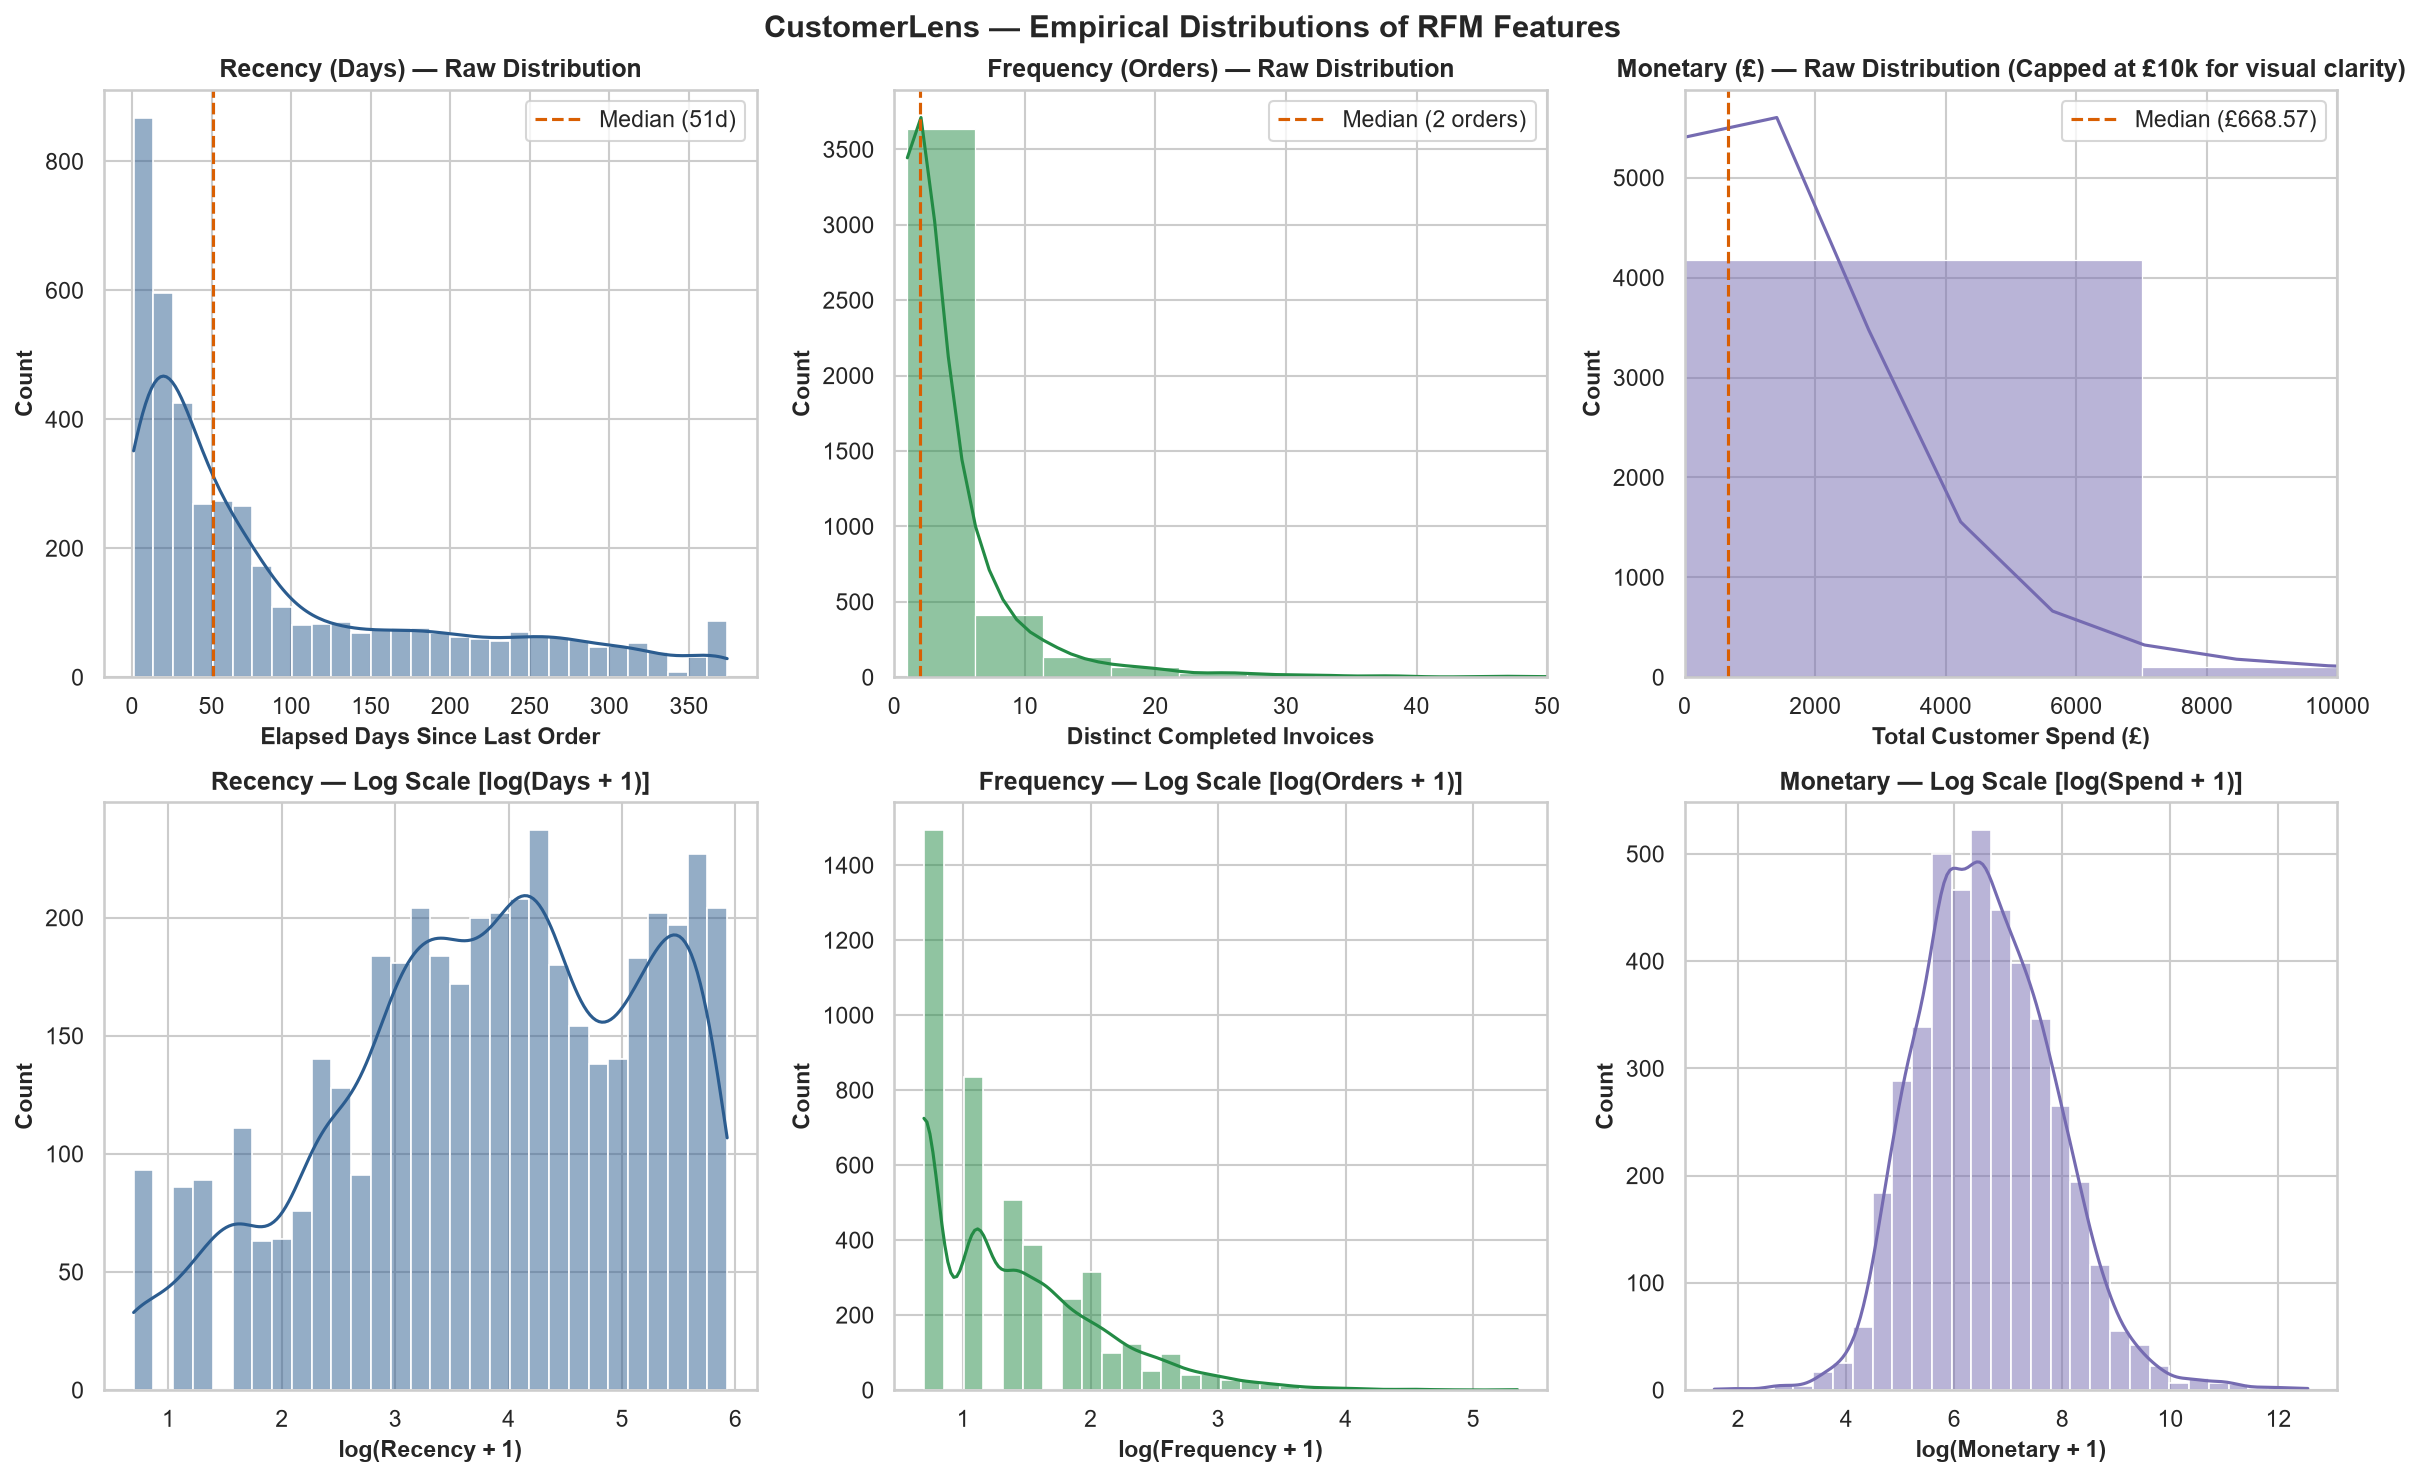

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("CustomerLens — Empirical Distributions of RFM Features", fontsize=15, y=0.98)

# Row 1: Raw Distributions
# Recency
sns.histplot(rfm["recency"], kde=True, ax=axes[0, 0], color="#2b5c8f", bins=30)
axes[0, 0].set_title("Recency (Days) — Raw Distribution")
axes[0, 0].set_xlabel("Elapsed Days Since Last Order")
axes[0, 0].axvline(rfm["recency"].median(), color="#d95f02", linestyle="--", label=f"Median ({rfm['recency'].median():.0f}d)")
axes[0, 0].legend()

# Frequency
sns.histplot(rfm["frequency"], kde=True, ax=axes[0, 1], color="#238b45", bins=40)
axes[0, 1].set_title("Frequency (Orders) — Raw Distribution")
axes[0, 1].set_xlabel("Distinct Completed Invoices")
axes[0, 1].axvline(rfm["frequency"].median(), color="#d95f02", linestyle="--", label=f"Median ({rfm['frequency'].median():.0f} orders)")
axes[0, 1].set_xlim(0, 50)
axes[0, 1].legend()

# Monetary
sns.histplot(rfm["monetary"], kde=True, ax=axes[0, 2], color="#756bb1", bins=40)
axes[0, 2].set_title("Monetary (£) — Raw Distribution (Capped at £10k for visual clarity)")
axes[0, 2].set_xlabel("Total Customer Spend (£)")
axes[0, 2].axvline(rfm["monetary"].median(), color="#d95f02", linestyle="--", label=f"Median (£{rfm['monetary'].median():.2f})")
axes[0, 2].set_xlim(0, 10000)
axes[0, 2].legend()

# Row 2: Log-Scaled Distributions (log1p)
# Log Recency
sns.histplot(np.log1p(rfm["recency"]), kde=True, ax=axes[1, 0], color="#2b5c8f", bins=30)
axes[1, 0].set_title("Recency — Log Scale [log(Days + 1)]")
axes[1, 0].set_xlabel("log(Recency + 1)")

# Log Frequency
sns.histplot(np.log1p(rfm["frequency"]), kde=True, ax=axes[1, 1], color="#238b45", bins=30)
axes[1, 1].set_title("Frequency — Log Scale [log(Orders + 1)]")
axes[1, 1].set_xlabel("log(Frequency + 1)")

# Log Monetary
sns.histplot(np.log1p(rfm["monetary"]), kde=True, ax=axes[1, 2], color="#756bb1", bins=30)
axes[1, 2].set_title("Monetary — Log Scale [log(Spend + 1)]")
axes[1, 2].set_xlabel("log(Monetary + 1)")

plt.tight_layout()
plt.show()


---

## 5. Outlier Inspection: Statistical Anomalies vs. Commercial Reality

A common data science error is automatically dropping statistical outliers ($> Q_3 + 1.5 \times \text{IQR}$). 
In transactional retail:
- Statistical outliers represent **key commercial wholesale accounts** (e.g. Customer `14646` who spent £280,206.02 across 73 orders).
- Deleting these customers would artificially erase over 20% of corporate turnover.
- **Decision:** Outliers are retained in the primary analytical dataset, and will receive log-scaling and robust scaling during Phase 9 K-Means clustering.


In [6]:
def inspect_outliers(df, col):
    q25 = df[col].quantile(0.25)
    q75 = df[col].quantile(0.75)
    iqr = q75 - q25
    upper_fence = q75 + 1.5 * iqr
    outliers = df[df[col] > upper_fence]
    return {
        "Feature": col,
        "Q1": round(q25, 2),
        "Q3": round(q75, 2),
        "IQR": round(iqr, 2),
        "Upper Fence": round(upper_fence, 2),
        "Outlier Count": len(outliers),
        "Outlier Pct": round(len(outliers) * 100.0 / len(df), 2),
        "Outlier Revenue Share": round(outliers["monetary"].sum() * 100.0 / df["monetary"].sum(), 2),
    }

outlier_summary = pd.DataFrame([
    inspect_outliers(rfm, "recency"),
    inspect_outliers(rfm, "frequency"),
    inspect_outliers(rfm, "monetary"),
])
display(outlier_summary)

print("\nTOP 10 SPENDING CUSTOMERS (COMMERCIAL WHLESALE ACCOUNTS):")
display(rfm.head(10)[["customerid", "recency", "frequency", "monetary", "country"]])


,Feature,Q1,Q3,IQR,Upper Fence,Outlier Count,Outlier Pct,Outlier Revenue Share
0,recency,18.00,142.0,124.00,328.00,155,3.57,0.63
1,frequency,1.00,5.0,4.00,11.00,285,6.57,46.56
2,monetary,306.48,1660.6,1354.12,3691.77,425,9.80,61.08



TOP 10 SPENDING CUSTOMERS (COMMERCIAL WHLESALE ACCOUNTS):


,customerid,recency,frequency,monetary,country
0,14646,2,73,280206.02,Netherlands
1,18102,1,60,259657.30,United Kingdom
2,17450,8,46,194390.79,United Kingdom
3,16446,1,2,168472.50,United Kingdom
4,14911,1,201,143711.17,EIRE
5,12415,24,21,124914.53,Australia
6,14156,10,55,117210.08,EIRE
7,17511,3,31,91062.38,United Kingdom
8,16029,39,63,80850.84,United Kingdom
9,12346,326,1,77183.60,United Kingdom


---

## 6. Skewness & Spearman / Pearson Correlation Analysis

We examine the relationships between Recency, Frequency, and Monetary spend:
- **Frequency vs. Monetary:** Expected strong positive correlation (customers who buy more frequently generate more cumulative spend).
- **Recency vs. Frequency / Monetary:** Negative correlation (active recent customers tend to have purchased more often and generated higher revenue than dormant buyers).


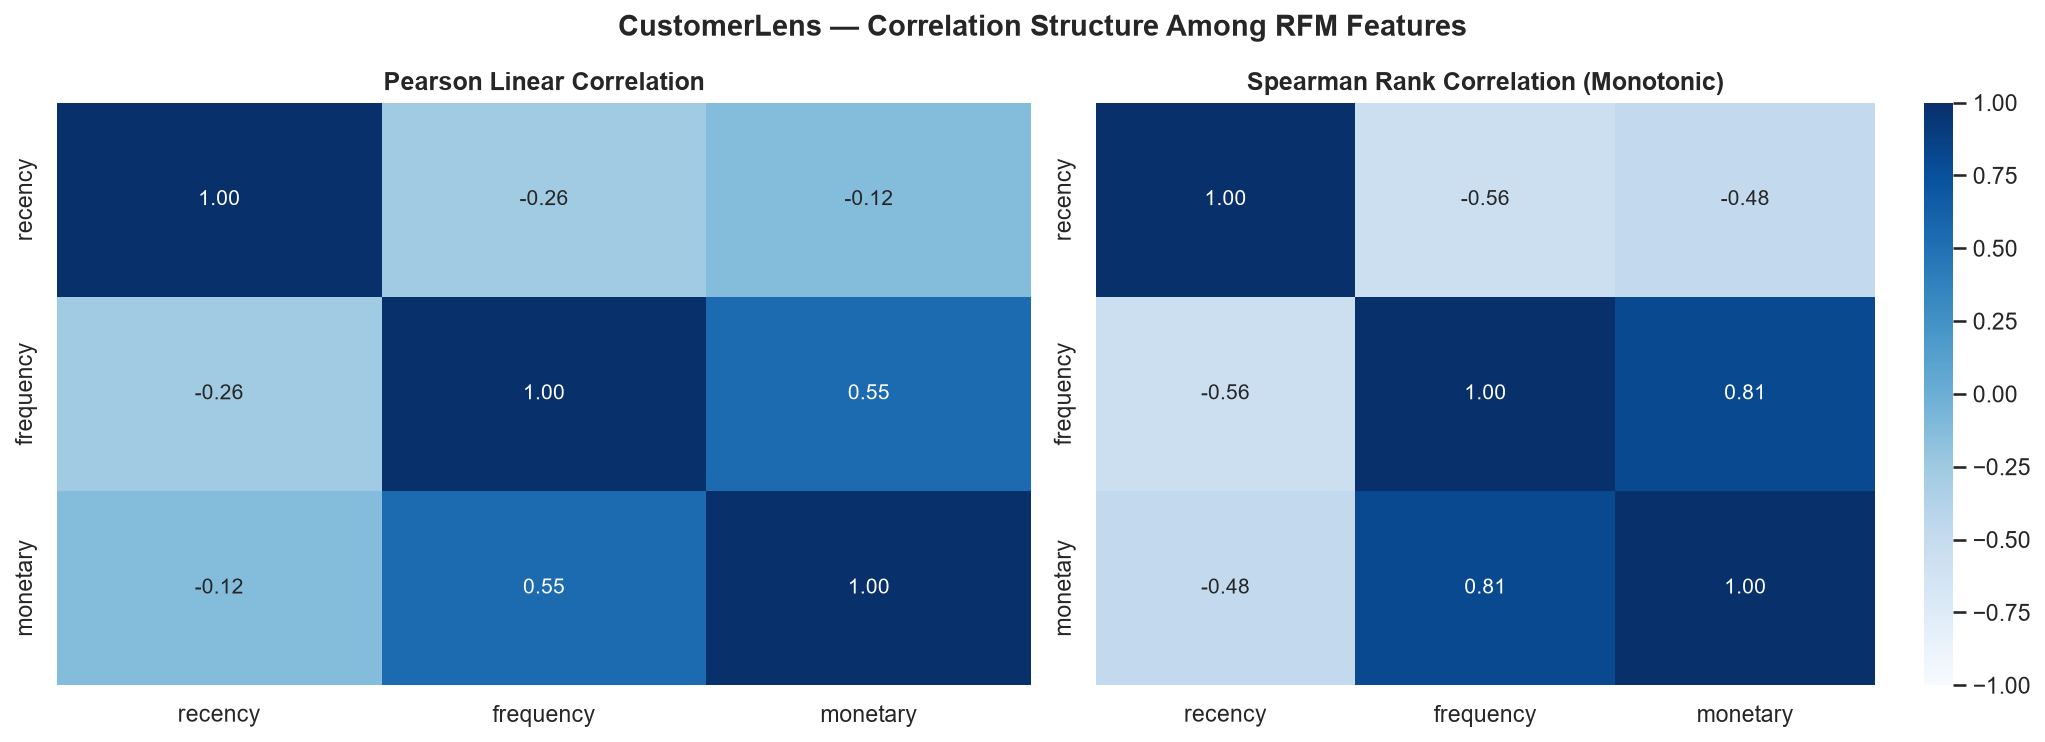

Spearman correlation between Frequency and Monetary: 0.807
Spearman correlation between Recency and Frequency:   -0.562
Spearman correlation between Recency and Monetary:    -0.481


In [7]:
pearson_corr = rfm[["recency", "frequency", "monetary"]].corr(method="pearson")
spearman_corr = rfm[["recency", "frequency", "monetary"]].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CustomerLens — Correlation Structure Among RFM Features", fontsize=14)

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Pearson Linear Correlation")

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman Rank Correlation (Monotonic)")

plt.tight_layout()
plt.show()

print(f"Spearman correlation between Frequency and Monetary: {spearman_corr.loc['frequency', 'monetary']:.3f}")
print(f"Spearman correlation between Recency and Frequency:   {spearman_corr.loc['recency', 'frequency']:.3f}")
print(f"Spearman correlation between Recency and Monetary:    {spearman_corr.loc['recency', 'monetary']:.3f}")


---

## 7. RFM Quantile Scoring & Tied-Boundary Resolution

We apply transparent quantile scoring (1 to 5) to each dimension:
- **$R\_Score$ (1 to 5):** Inverted so that lower Recency (more recent) receives a higher score (5 = most recent).
- **$F\_Score$ (1 to 4/5):** Higher Frequency receives a higher score. Handled via `pd.qcut(..., duplicates='drop')` to prevent crashes caused by tied values at 1 and 2 orders.
- **$M\_Score$ (1 to 5):** Higher Monetary spend receives a higher score (5 = top 20% spenders).
- **$RFM\_Score$:** Combined 3-digit string (e.g. `'545'`).


C:\Users\divya\AppData\Local\Temp\ipykernel_31672\2723147398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=scored_rfm["R_score"], ax=axes[0], palette="Blues")
C:\Users\divya\AppData\Local\Temp\ipykernel_31672\2723147398.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=scored_rfm["F_score"], ax=axes[1], palette="Greens")
C:\Users\divya\AppData\Local\Temp\ipykernel_31672\2723147398.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=scored_rfm["M_score"], ax=axes[2], palette="Purples")


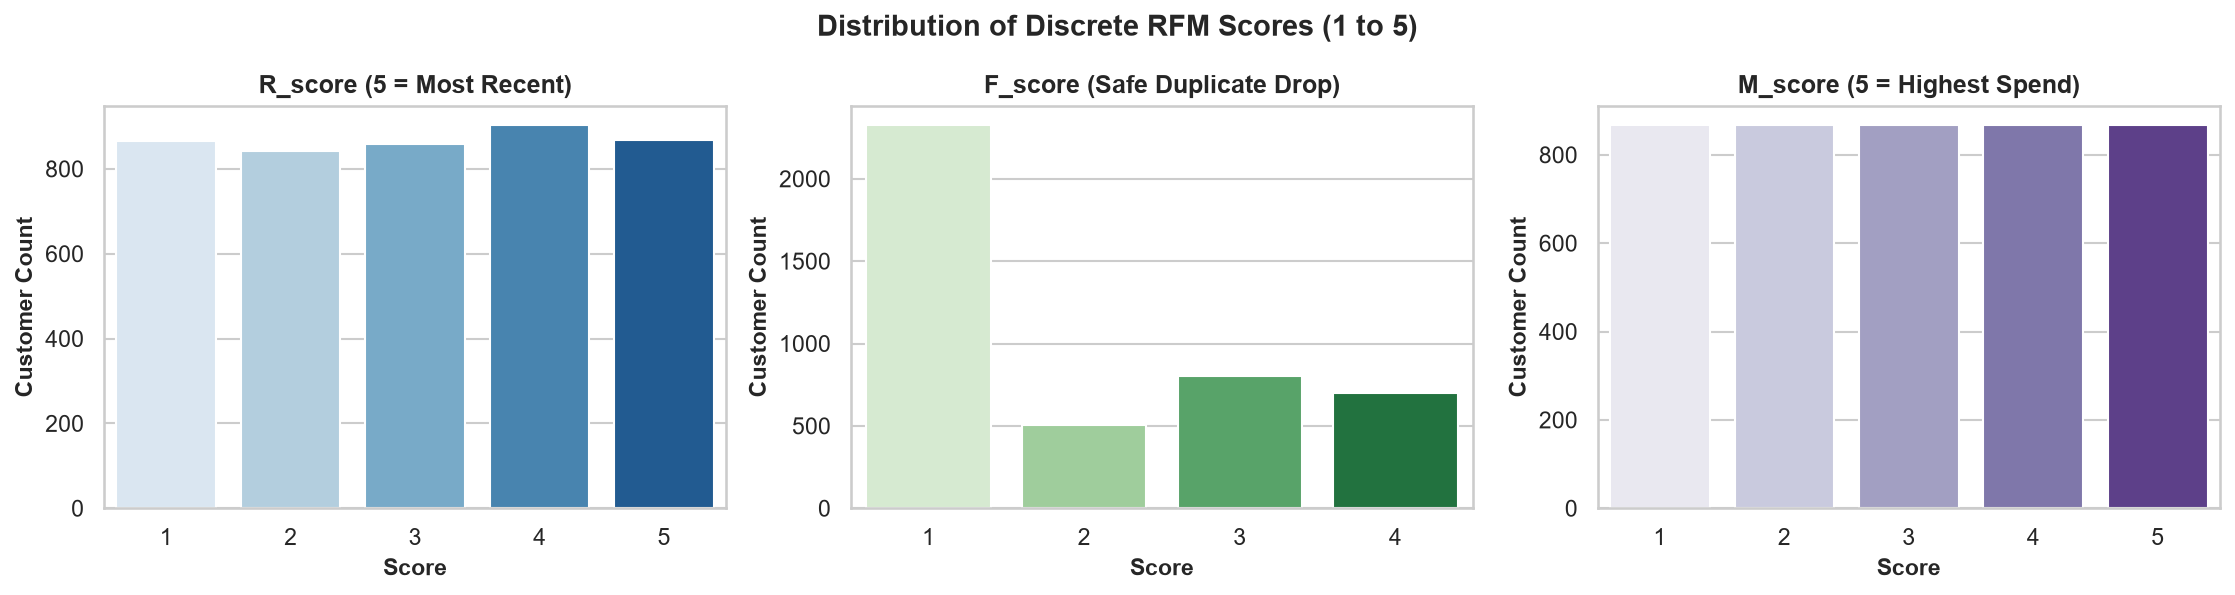

Top 10 Most Common RFM Score Strings:


,customer_count
RFM_score,
111,357
545,323
112,263
211,169
212,159
312,158
445,154
311,151
213,150


In [8]:
scored_rfm = calculate_rfm_scores(rfm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution of Discrete RFM Scores (1 to 5)", fontsize=14)

sns.countplot(x=scored_rfm["R_score"], ax=axes[0], palette="Blues")
axes[0].set_title("R_score (5 = Most Recent)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Customer Count")

sns.countplot(x=scored_rfm["F_score"], ax=axes[1], palette="Greens")
axes[1].set_title("F_score (Safe Duplicate Drop)")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Customer Count")

sns.countplot(x=scored_rfm["M_score"], ax=axes[2], palette="Purples")
axes[2].set_title("M_score (5 = Highest Spend)")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Customer Count")

plt.tight_layout()
plt.show()

print("Top 10 Most Common RFM Score Strings:")
display(scored_rfm["RFM_score"].value_counts().head(10).to_frame("customer_count"))


---

## 8. Score Distributions & 2D RFM Heatmaps

We cross-tabulate Recency vs. Frequency scores to inspect customer density and average monetary yield across the 2D behavioral grid.


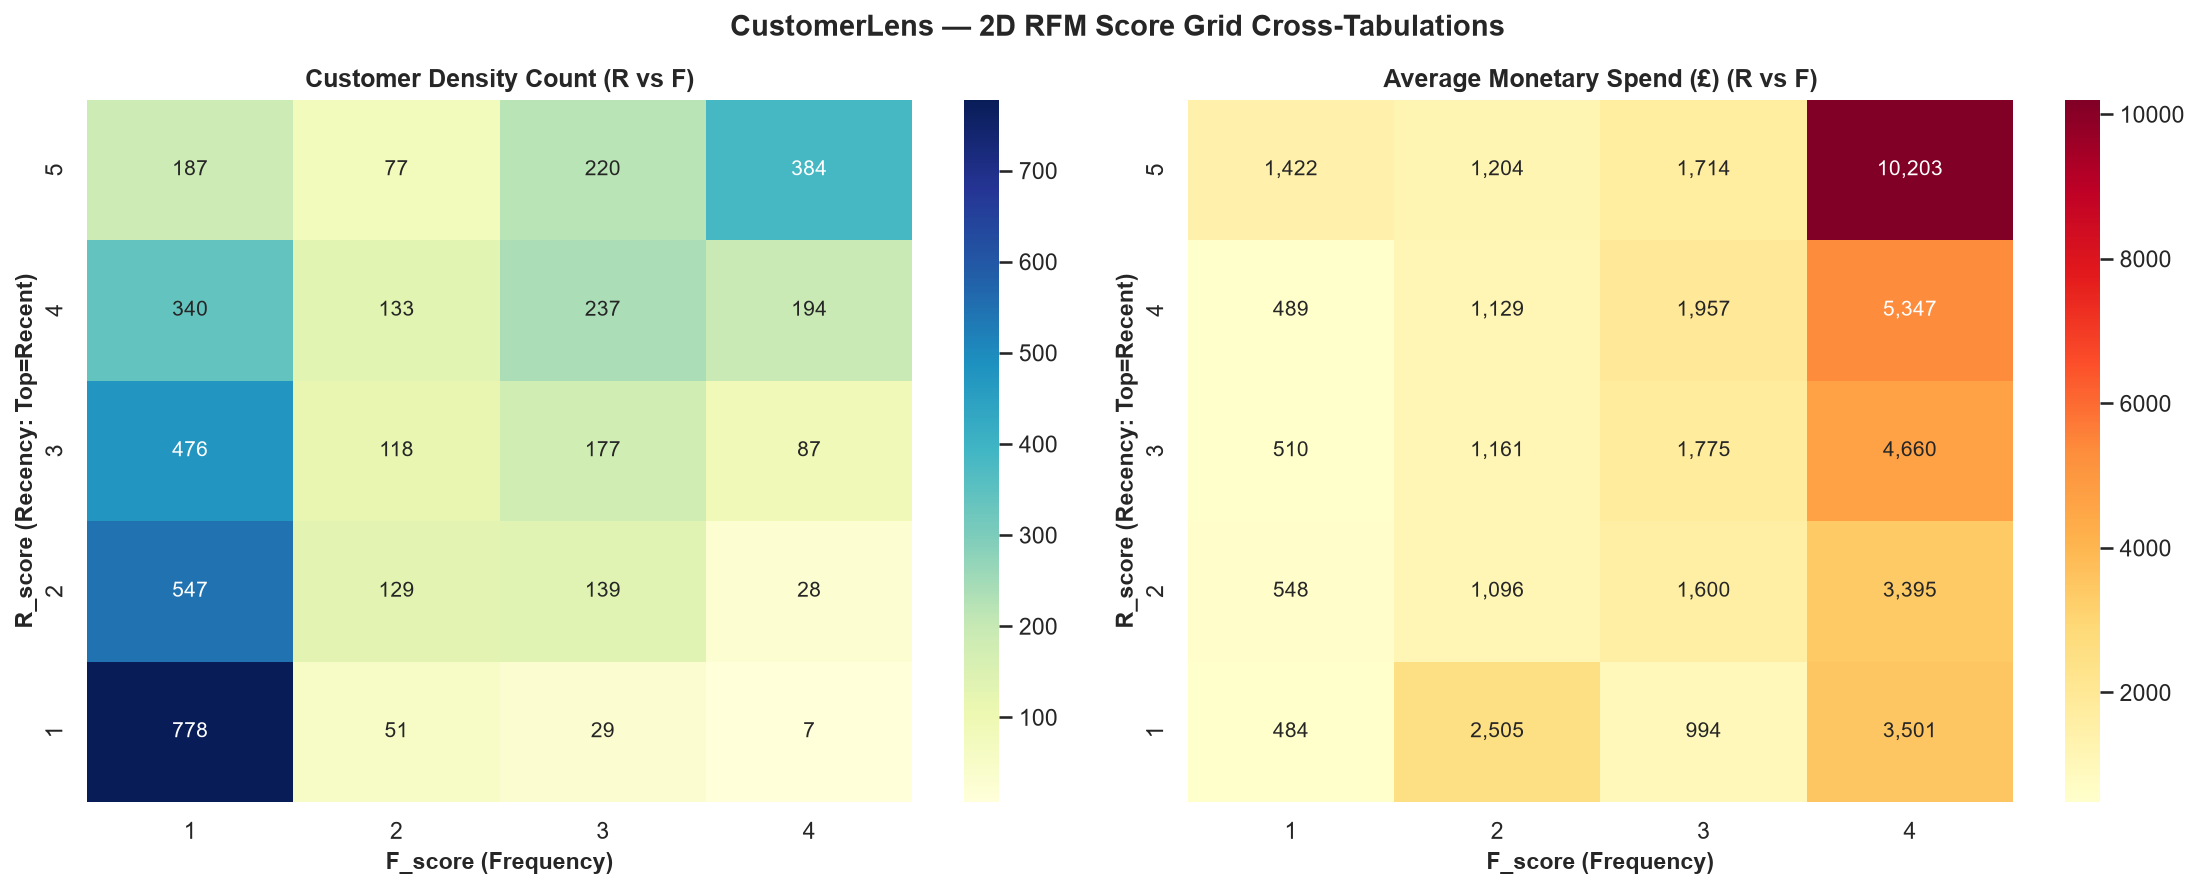

In [9]:
count_pivot = scored_rfm.pivot_table(
    index="R_score", columns="F_score", values="customerid", aggfunc="count"
).sort_index(ascending=False)

monetary_pivot = scored_rfm.pivot_table(
    index="R_score", columns="F_score", values="monetary", aggfunc="mean"
).sort_index(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("CustomerLens — 2D RFM Score Grid Cross-Tabulations", fontsize=14)

sns.heatmap(count_pivot, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Customer Density Count (R vs F)")
axes[0].set_xlabel("F_score (Frequency)")
axes[0].set_ylabel("R_score (Recency: Top=Recent)")

sns.heatmap(monetary_pivot, annot=True, fmt=",.0f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Average Monetary Spend (£) (R vs F)")
axes[1].set_xlabel("F_score (Frequency)")
axes[1].set_ylabel("R_score (Recency: Top=Recent)")

plt.tight_layout()
plt.show()


---

## 9. Rule-Based Analytical Customer Segmentation

Using the RFM grid, we assign customers to 8 transparent, deterministic behavioral segments:
1. **Champions:** $R \ge 4, F \ge 4$ (Recent, highly frequent repeat buyers)
2. **Loyal Customers:** $R \ge 3, F \ge 3$ (Consistent purchasers)
3. **Potential Loyalists:** $R \ge 4, F \in [2, 3]$ (Recent buyers with growing frequency)
4. **Recent Customers:** $R \ge 4, F = 1$ (Brand new or recent single-order buyers)
5. **At Risk:** $R \le 2, F \ge 3$ (Valuable repeat buyers who have become inactive)
6. **Need Attention:** $R = 3, F \in [1, 2]$ (Average recency and frequency)
7. **Hibernating:** $R = 2, F \le 2$ (Low recency, low frequency)
8. **Lost:** $R = 1, F \le 2$ (Oldest recency, lowest frequency)


CUSTOMERLENS RFM SEGMENT SCORECARD


,segment,customer_count,total_revenue,total_orders,mean_recency,median_recency,mean_frequency,median_frequency,mean_monetary,median_monetary,pct_customers,pct_revenue,aov
0,Champions,578,4955312.49,8864,11.1,9.0,15.34,11.0,8573.20,3951.22,13.32,55.76,559.04
1,Loyal Customers,721,1560523.17,3852,28.0,24.0,5.34,5.0,2164.39,1572.71,16.62,17.56,405.12
2,Lost,829,504421.20,1088,269.8,264.0,1.31,1.0,608.47,293.45,19.11,5.68,463.62
3,Hibernating,676,441154.18,1145,118.4,114.0,1.69,2.0,652.59,448.68,15.58,4.96,385.29
4,Recent Customers,527,432278.08,812,17.6,18.0,1.54,2.0,820.26,361.96,12.15,4.86,532.36
5,Need Attention,594,379807.42,1012,53.1,53.0,1.70,2.0,639.41,430.17,13.69,4.27,375.30
6,At Risk,203,370799.28,1129,131.3,109.0,5.56,5.0,1826.60,1431.93,4.68,4.17,328.43
7,Potential Loyalists,210,242913.07,630,17.5,19.0,3.00,3.0,1156.73,876.00,4.84,2.73,385.58


C:\Users\divya\AppData\Local\Temp\ipykernel_31672\1970607328.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_table, y="segment", x="customer_count", palette=palette, ax=axes[0])
C:\Users\divya\AppData\Local\Temp\ipykernel_31672\1970607328.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_table, y="segment", x="pct_revenue", palette=palette, ax=axes[1])


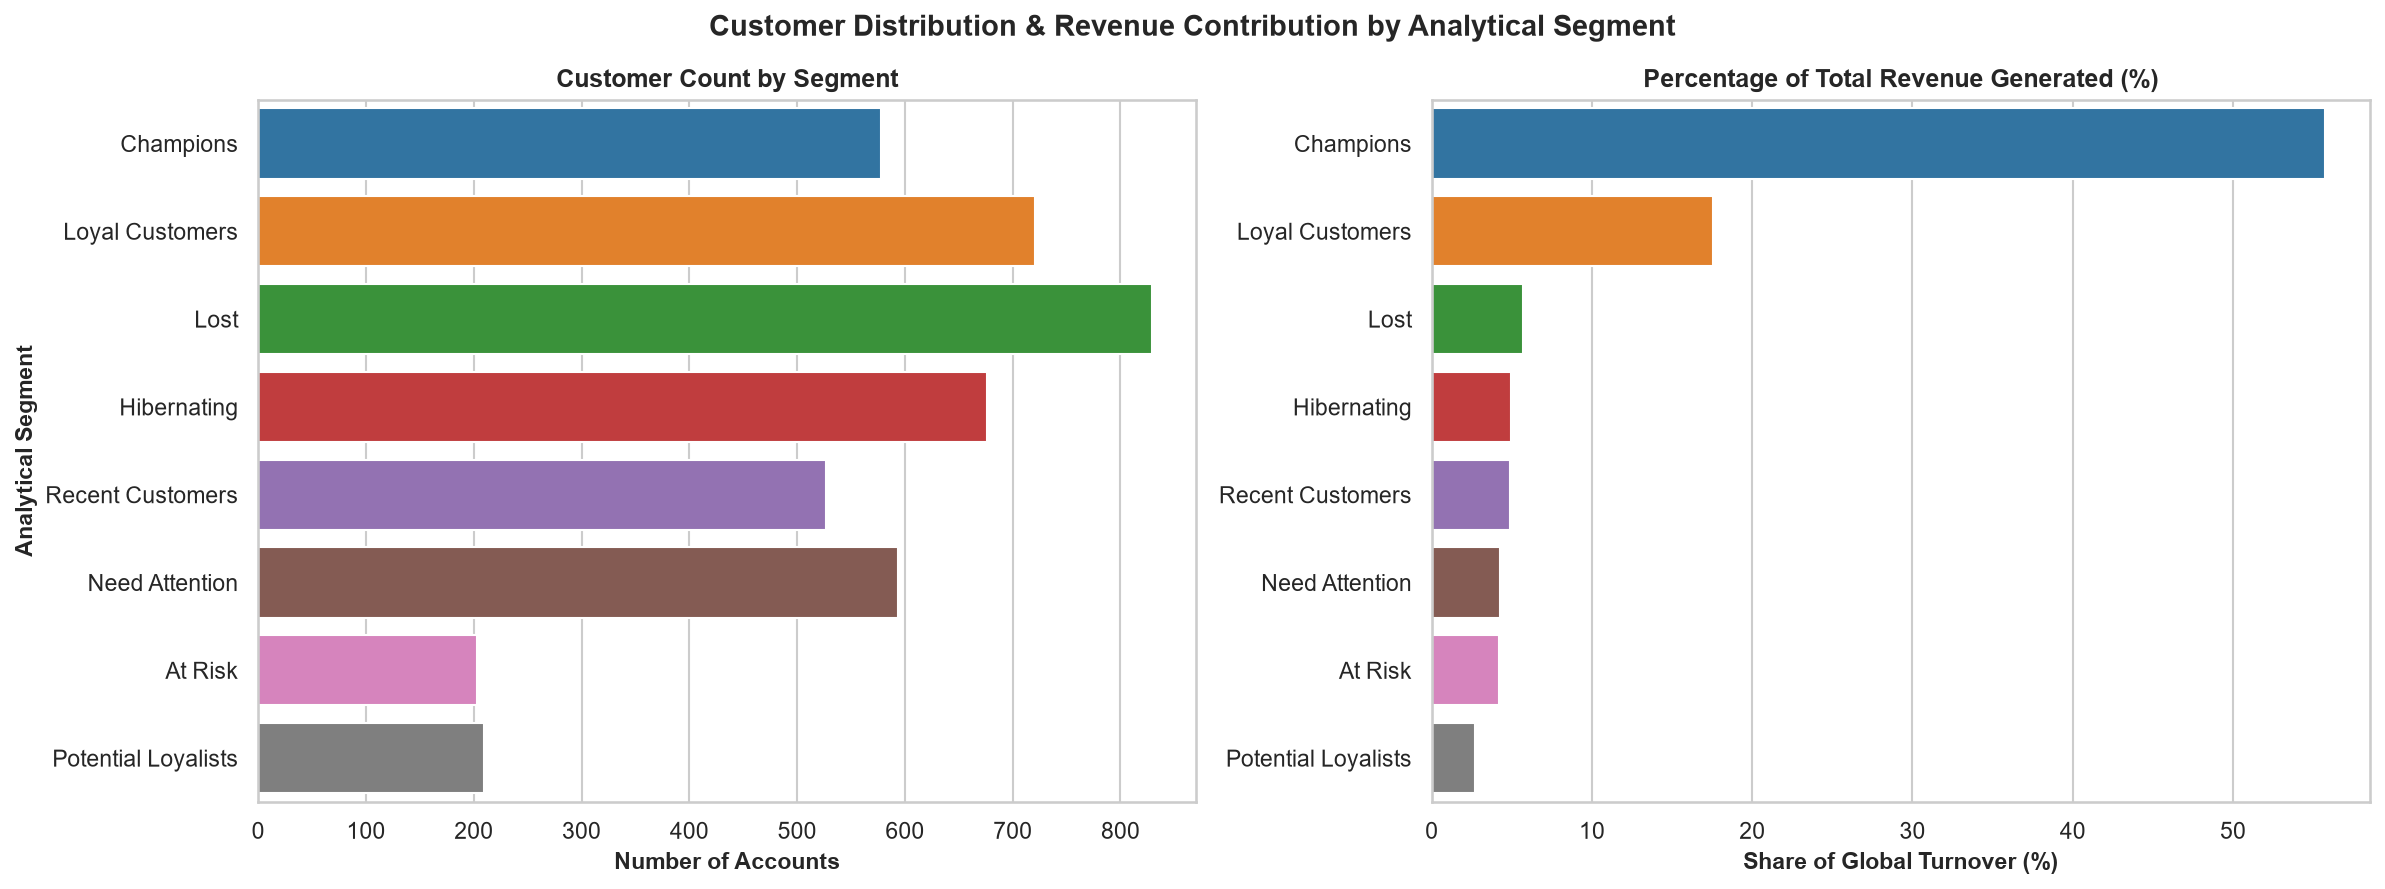

In [10]:
segmented_rfm = assign_rfm_segments(scored_rfm)
summary_table = summarize_rfm(segmented_rfm)

print("=" * 80)
print("CUSTOMERLENS RFM SEGMENT SCORECARD")
print("=" * 80)
display(summary_table)

# Plot Segment Customer Count and Revenue Share
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Customer Distribution & Revenue Contribution by Analytical Segment", fontsize=14)

palette = sns.color_palette("tab10", len(summary_table))

sns.barplot(data=summary_table, y="segment", x="customer_count", palette=palette, ax=axes[0])
axes[0].set_title("Customer Count by Segment")
axes[0].set_xlabel("Number of Accounts")
axes[0].set_ylabel("Analytical Segment")

sns.barplot(data=summary_table, y="segment", x="pct_revenue", palette=palette, ax=axes[1])
axes[1].set_title("Percentage of Total Revenue Generated (%)")
axes[1].set_xlabel("Share of Global Turnover (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


---

## 10. Commercial Hypotheses & Transition to Phase 9 K-Means Clustering

### Strategic Hypotheses for Targeted Retention
- **Champions & Loyal Customers (~30% of accounts):** Account for over 70% of total revenue. Recommend VIP retention, early product access, and dedicated account support.
- **Potential Loyalists (~5% of accounts):** Show promise with 2–3 purchases. Candidate for basket-building cross-sell recommendations.
- **At Risk (~5% of accounts):** Previously frequent buyers who have lapsed. Ideal candidates for re-engagement win-back outreach (subject to A/B testing).
- **Recent Customers (~12% of accounts):** Onboarding nurture series to drive conversion from first to second purchase.

---

### Bridge to Phase 9 (K-Means Clustering)
While rule-based RFM segments provide an intuitive heuristic scorecard, they rely on rigid rectangular partitions in the 3D space. 
In **Phase 9**, we will apply unsupervised machine learning (**K-Means Clustering**):
1. **Power Transforms & Scaling:** Apply `np.log1p` and `StandardScaler` to handle extreme monetary/frequency skewness.
2. **Mathematical Cluster Optimization:** Use the Elbow Method (Inertia) and Silhouette Analysis to identify natural continuous clusters.
3. **Cross-Validation:** Benchmark machine learning clusters against our rule-based RFM segments to evaluate cluster alignment.


In [11]:
# Persist validated dataset to data/processed/rfm_customer_metrics.csv
output_path = save_rfm_dataset(segmented_rfm)
print(f"Successfully saved validated RFM dataset ({len(segmented_rfm):,} rows) to: {output_path}")


Successfully saved validated RFM dataset (4,338 rows) to: C:\Users\divya\OneDrive\Desktop\Customer_Lens\data\processed\rfm_customer_metrics.csv
